# Аналіз A/B-тесту: чи варто пересувати ворота у грі Cookie Cats?

[Cookie Cats](https://www.facebook.com/cookiecatsgame) — мобільна головоломка в стилі «з'єднай три», де гравець з'єднує плитки одного кольору, щоб очистити дошку та виграти рівень. Одна з ключових механік гри — **ворота (gates)**: примусові паузи, які змушують гравця зачекати або зробити покупку в додатку, перш ніж продовжити гру.

Продуктова команда вирішила перевірити: **що станеться з утриманням гравців, якщо перемістити перші ворота з рівня 30 на рівень 40?** Для цього було проведено A/B-тест: гравців випадково ділили на дві групи — тих, хто натрапляв на ворота на 30-му рівні (`gate_30`, контроль), і тих, хто на 40-му (`gate_40`, тест).

Як аналітикиня, я отримала дані цього тесту. Моє завдання — статистично обґрунтувати, яке рішення слід ухвалити продуктовій команді.

---

**Дані:** файл `cookie_cats.csv` з наступними колонками:

- `userid` — унікальний номер, який ідентифікує кожного гравця.
- `version` — чи потрапив гравець в контрольну групу (gate_30 — ворота на 30 рівні) чи тестову групу (gate_40 — ворота на 40 рівні).
- `sum_gamerounds` — кількість ігрових раундів, зіграних гравцем протягом першого тижня після встановлення
- `retention_1` — чи через 1 день після встановлення гравець повернувся і почав грати?
- `retention_7` — чи через 7 днів після встановлення гравець повернувся і почав грати?

## Крок 1. Планування тесту: скільки даних потрібно?

Перш ніж інтерпретувати результати, хочу переконатися, що зібраних даних достатньо для виявлення очікуваного ефекту. Продакт-менеджер повідомив, що поточне базове утримання становить **19 %**, а мінімально значущим покращенням вважатимемо **+1 п.п.** (до 20 %). Розрахую мінімальний розмір вибірки при потужності тесту 80 % і рівні значущості α = 0.05.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.stats.api as sms
from math import ceil

%matplotlib inline

In [2]:
# Розрахунок розміру ефекту на основі очікуваних показників
effect_size = sms.proportion_effectsize(0.20, 0.19)
effect_size

np.float64(0.025241594409087353)

In [3]:
# Спочатку розрахунок необхідного розміру вибірки
required_n = sms.NormalIndPower().solve_power(
    effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1
)

# Далі округлення до наступного цілого числа
required_n = ceil(required_n)
required_n

24638

In [4]:
total_required_n = 2 * required_n
total_required_n

49276

**Сумарно** нам треба **мінімум 49276 користувачів** аби досягнути очікуваного ефекту.

## Крок 2. Завантаження даних та первинний аналіз утримання

Завантажую дані й перевіряю, чи достатньо спостережень для тесту. Також обчислюю середнє утримання на 7-й день по кожній групі та формулюю гіпотезу.

In [5]:
df = pd.read_csv('Data/cookie_cats.csv')
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


**Гіпотези:**
- $H_0$: $p_{30}$ = $p_{40}$ - статистично значущої різниці в поведінці користувачів у версіях `gate_30` та `gate_40` НЕМАЄ;
- $H_a$: $p_{30}$ ≠ $p_{40}$ - статистично значуща різниця в поведінці користувачів у версіях `gate_30` та `gate_40` Є.

In [6]:
# Переконаємося, що маємо лише 2 групи: контрольна та тестова
df['version'].unique()

array(['gate_30', 'gate_40'], dtype=object)

In [7]:
# Так як даних 90189, а нам треба мінімум 49276 - приймаємо рішення використовувати всі дані, що є (як зазвичай в роботі)
ab_test = df.copy()

In [8]:
retention_rates = (
    ab_test.groupby('version')['retention_7']
    .agg(['mean', 'std', stats.sem])
)
    
retention_rates.columns = [
    'retention_rate',
    'std_deviation',
    'std_error'
]

retention_rates.style.format('{:.5f}')

,retention_rate,std_deviation,std_error
version,,,
gate_30,0.19020,0.39246,0.00186
gate_40,0.18200,0.38585,0.00181


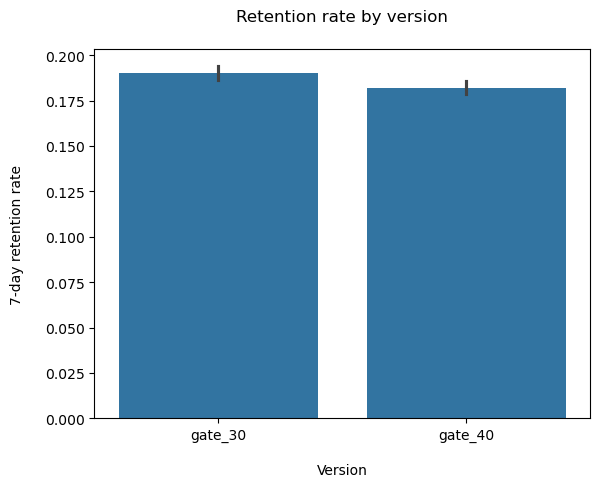

In [9]:
sns.barplot(
    data=ab_test,
    x='version',
    y='retention_7'
)

plt.title('Retention rate by version', pad=20)
plt.xlabel('Version', labelpad=15)
plt.ylabel('7-day retention rate', labelpad=15);

Через 7 днів після встановлення гри версія `gate_30` дає краще утримання (**коефіцієнт утримання 19.02 % проти 18.2 %**).

## Крок 3. Z-тест: чи є різниця статистично значущою?

Візуально `gate_30` виглядає краще, але різниця невелика. Перевіряю за допомогою двовибіркового Z-тесту для пропорцій, чи є ця різниця статистично значущою (α = 0.05). Також обчислю довірчі інтервали для обох груп, щоб зрозуміти, наскільки стабільна різниця між ними.

In [10]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

In [11]:
control_results = ab_test[
    ab_test['version'] == 'gate_30'
]['retention_7']

treatment_results = ab_test[
    ab_test['version'] == 'gate_40'
]['retention_7']

In [12]:
n_con = control_results.count()
n_treat = treatment_results.count()

nobs = [n_con, n_treat]
nobs

[np.int64(44700), np.int64(45489)]

In [13]:
successes = [
    control_results.sum(),
    treatment_results.sum()
]

successes

[np.int64(8502), np.int64(8279)]

In [14]:
z_stat, p_value = proportions_ztest(successes, nobs)

(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(
    successes,
    nobs=nobs,
    alpha=0.05,
    method='wilson'
)

print(f'z statistic: {z_stat:.3f}')
print(f'p-value: {p_value:.4f}')

print(
    f'Довірчий інтервал 95 % для групи control: '
    f'[{lower_con:.4f}, {upper_con:.4f}]'
)

print(
    f'Довірчий інтервал 95 % для групи treatment: '
    f'[{lower_treat:.4f}, {upper_treat:.4f}]'
)

z statistic: 3.164
p-value: 0.0016
Довірчий інтервал 95 % для групи control: [0.1866, 0.1939]
Довірчий інтервал 95 % для групи treatment: [0.1785, 0.1856]


**Висновок:**
- A. Оскільки p-value = 0.0016, а рівень значущості $\alpha$ = 0.05, то:
  - p-value < $\alpha$;
  - нульову гіпотезу ($H_0$) відхиляємо. Отже, різниця в поведінці користувачів у різних версіях гри є статистично значущою.
- B. Довірчі інтервали утримання користувачів у різних версіях гри не перетинаються, оскільки верхня межа `treatment` (0.1856) менша за нижню межу `control` (0.1866). Це свідчить про те, що різниця між групами є помітною та стабільною, утримання користувачів у групі `control` вище, ніж у `treatment`, а результат статистичного тесту підтверджується довірчим інтервалом.

## Крок 4. χ²-тест: незалежна перевірка результату

Щоб підтвердити висновок з Z-тесту, застосовую χ²-тест незалежності. Він дозволить перевірити, чи є залежність між версією гри і тим, чи повернувся гравець на 7-й день, не покладаючись на ті ж самі припущення, що й Z-тест.

**Сформульовані гіпотези:**
- $H_0$: `version` ⟂ `retention_7` (незалежні змінні) - версія гри НЕ впливає на утримання гравця на 7-й день після реєстрації;
- $H_a$: `version` ∉⊥ `retention_7` (залежні змінні) - версія гри ВПЛИВАЄ на утримання гравця на 7-й день після реєстрації.

In [15]:
contingency_table = pd.crosstab(
    ab_test['version'],
    ab_test['retention_7']
)

contingency_table

retention_7,False,True
version,,
gate_30,36198,8502
gate_40,37210,8279


In [16]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print(f'χ² statistic: {chi2:.3f}')
print(f'p-value: {p_value:.4f}')
print(f'Ступені свободи: {dof}')
print(f'Очікувані частоти:\n {expected.round(2)}')

χ² statistic: 9.959
p-value: 0.0016
Ступені свободи: 1
Очікувані частоти:
 [[36382.9  8317.1]
 [37025.1  8463.9]]


**Висновок:** За результатами тесту відхиляємо $H_0$, оскільки p-value < $\alpha$ (0.0016 < 0.05). Отже, існує залежність між версією гри та утриманням гравця на 7-й день після реєстрації. Отримали той самий результат, що й із Z-тестом: статистично значуща різниця є.

---

## Підсумок та рекомендація

Обидва тести (Z-тест і χ²-тест) дають однаковий результат: **переміщення воріт з рівня 30 на рівень 40 статистично значуще знижує 7-денне утримання гравців** (з 19.02 % до 18.20 %, p = 0.0016). Довірчі інтервали двох груп не перетинаються, що підтверджує стабільність ефекту.

**Рекомендація:** залишити ворота на рівні 30. Ворота на ранніх рівнях формують звичку повертатися до гри — прибираючи цю точку взаємодії, ми втрачаємо гравців раніше, ніж вони встигають звикнути до щоденної гри.